In [417]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# Define pastel color palette
COLOR_INCIDENCE = '#6B9AC4'  # Pastel Blue
COLOR_MORTALITY = '#E5989B'  # Pastel Red
COLOR_BARS = ['#6B9AC4', '#B8A3C3', '#E5989B']  # Pastel Blue -> Lavender -> Pastel Red

# Clean, modern global styling
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#111111',
    'axes.linewidth': 1.0,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlecolor': '#111111',
    'axes.titlepad': 12,
    'axes.labelsize': 10,
    'axes.labelweight': 'bold',
    'axes.labelcolor': '#111111',
    'xtick.color': '#111111',
    'ytick.color': "#111111",
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'grid.color': '#ffffff',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,
    'legend.frameon': True,
    'legend.facecolor': '#fafafa',
    'legend.edgecolor': '#111111',
    'legend.fontsize': 12,
    'axes.facecolor': '#ffffff',
    'axes.grid': True,         # Enables grid rendering globally
    'grid.color': '#B0B0B0',     # Light gray (replaces invisible #ffffff)
    'grid.linestyle': '--',
    'grid.alpha': 0.8,
})

print("Theme initialized with pastel color scheme.")

Theme initialized with pastel color scheme.


In [418]:
import pandas as pd

# Step 1: Print the first 15 lines of the raw file to inspect its actual structure
with open("../data/raw/all_cancers_combined.csv", "r") as f:
  for i in range(15):
    print(f"Line {i}: {f.readline().strip()}")

Line 0: "Cancer Site Comparison"
Line 1: "Recent Trends in U.S. Age-Adjusted Mortality Rates, 2000-2024"
Line 2: "By Cancer Site, Both Sexes, All Races / Ethnicities, All Ages"
Line 3: 
Line 4: "","All Cancer Sites Combined","All Cancer Sites Combined","All Cancer Sites Combined","All Cancer Sites Combined","Anus, Anal Canal &amp; Anorectum","Anus, Anal Canal &amp; Anorectum","Anus, Anal Canal &amp; Anorectum","Anus, Anal Canal &amp; Anorectum","Bones and Joints","Bones and Joints","Bones and Joints","Bones and Joints","Brain and Other Nervous System","Brain and Other Nervous System","Brain and Other Nervous System","Brain and Other Nervous System","Female Breast","Female Breast","Female Breast","Female Breast","Cervix Uteri","Cervix Uteri","Cervix Uteri","Cervix Uteri","Colon and Rectum (including Appendix)","Colon and Rectum (including Appendix)","Colon and Rectum (including Appendix)","Colon and Rectum (including Appendix)","Corpus and Uterus, NOS","Corpus and Uterus, NOS","Corpus a

In [419]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 2: Load the CSV using header=0 or auto-detecting the table start
# Let's read the file and skip lines that don't look like tabular data
df = pd.read_csv(
    "../data/raw/all_cancers_combined.csv",
    skiprows=9,  # Adjust this if your printout above shows headers elsewhere
    on_bad_lines="skip",
)

# Clean column names
df.columns = df.columns.str.strip()
print("Columns detected:", df.columns.tolist())
display(df.head())

Columns detected: ['2003', '190.9745', '190.4724', '191.4777', '190.5876', '0.1886', '0.1732', '0.2050', '0.1891', '0.4328', '0.4092', '0.4574', '0.4390', '4.4014', '4.3256', '4.4781', '4.3706', '25.2793', '25.0357', '25.5248', '25.0734', '2.4872', '2.4095', '2.5667', '2.4582', '19.1859', '19.0267', '19.3460', '18.9902', '4.1407', '4.0431', '4.2402', '4.1573', '4.3803', '4.3048', '4.4569', '4.3961', '0.0789', '0.0690', '0.0898', '0.0769', '0.6568', '0.6277', '0.6869', '0.6665', '0.4625', '0.4381', '0.4879', '0.4518', '4.1952', '4.1213', '4.2702', '4.1650', '1.2877', '1.2470', '1.3295', '1.2777', '7.4555', '7.3562', '7.5557', '7.4464', '0.4915', '0.4663', '0.5177', '0.4836', '1.5515', '1.5063', '1.5977', '1.5216', '2.7958', '2.7352', '2.8573', '2.7616', '0.4244', '0.4010', '0.4488', '0.4222', '0.0418', '0.0347', '0.0500', '0.0378', '5.0166', '4.9357', '5.0985', '5.0120', '54.1548', '53.8876', '54.4229', '54.0974', '2.6686', '2.6096', '2.7285', '2.6808', '3.7161', '3.6463', '3.7869', '3.

,2003,190.9745,190.4724,191.4777,190.5876,0.1886,0.1732,0.2050,0.1891,0.4328,...,4.3834,4.3874,0.2269,0.2048,0.2508,0.2319,0.4490,0.4177,0.4820,0.4580
0,2004,186.9269,186.4335,187.4212,187.6994,0.1971,0.1815,0.2138,0.1950,0.4386,...,4.5094,4.3933,0.2406,0.2178,0.2651,0.2292,0.4613,0.4297,0.4946,0.4635
1,2005,185.3164,184.8292,185.8047,184.8549,0.1899,0.1748,0.2061,0.2011,0.4638,...,4.5025,4.3992,0.2156,0.1944,0.2387,0.2265,0.4549,0.4238,0.4877,0.4691
2,2006,182.1193,181.6402,182.5994,182.0535,0.1999,0.1844,0.2163,0.2073,0.4409,...,4.4914,4.4052,0.2219,0.2004,0.2452,0.2239,0.4737,0.4423,0.5068,0.4748
3,2007,179.3352,178.8639,179.8074,179.2946,0.2020,0.1866,0.2184,0.2138,0.4410,...,4.5244,4.4111,0.2068,0.1862,0.2292,0.2213,0.4700,0.4388,0.5029,0.4805
4,2008,176.3980,175.9348,176.8621,176.5775,0.2198,0.2039,0.2366,0.2205,0.4315,...,4.4904,4.4170,0.2263,0.2048,0.2496,0.2187,0.4927,0.4610,0.5261,0.4863


,Cancer Type,Mortality Rate (2024),Difference vs Pancreas,Ratio vs Pancreas
0,Lung and Bronchus,139.4517,0.2451,1.001761
1,Pancreas,139.2066,0.0000,1.000000
2,Colon and Rectum,139.0992,-0.1074,0.999228
3,Prostate,138.7473,-0.4593,0.996701
4,Female Breast,28.0576,-111.1490,0.201554
5,Liver and Intrahepatic Bile Duct,27.9692,-111.2374,0.200919
6,Leukemia,27.9028,-111.3038,0.200442
7,Non-Hodgkin Lymphoma,27.7486,-111.4580,0.199334
8,Stomach,18.8284,-120.3782,0.135255
9,Esophagus,18.6465,-120.5601,0.133948


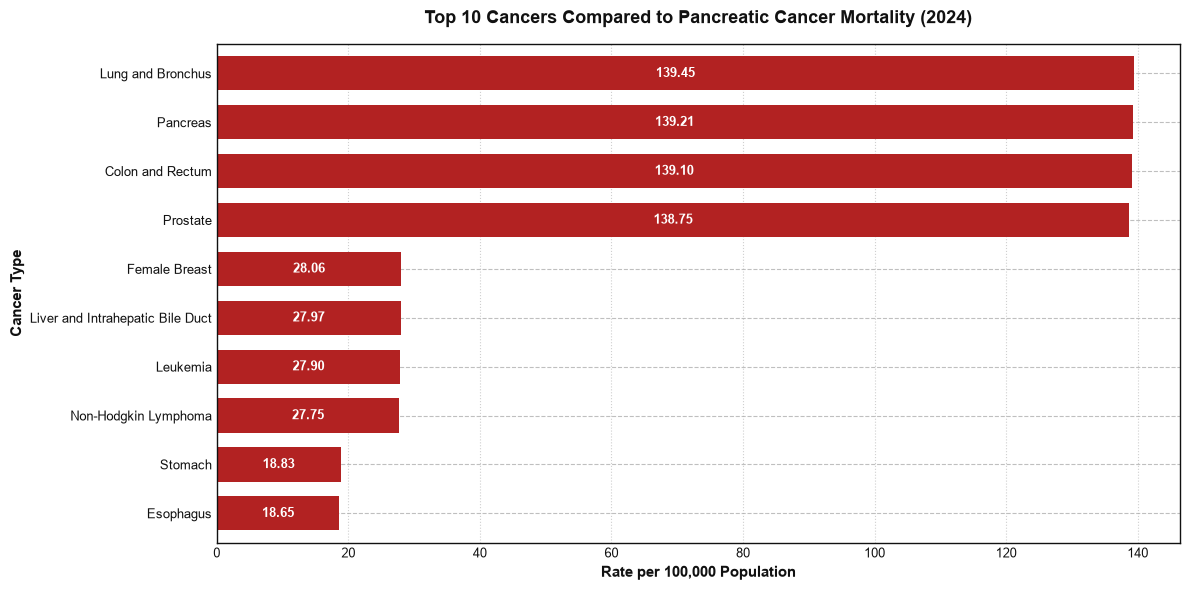

In [420]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# Load the CSV file, skipping initial metadata header rows
df = pd.read_csv("../data/raw/all_cancers_combined.csv", skiprows=9)
df.columns = df.columns.str.strip()

# The first column contains the Year
year_col = df.columns[0]

# Clean and filter valid year rows
df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
df = df.dropna(subset=[year_col]).copy()
df[year_col] = df[year_col].astype(int)
df.set_index(year_col, inplace=True)

# Coerce data columns to numeric
numeric_df = df.apply(pd.to_numeric, errors="coerce")
numeric_df = numeric_df.dropna(how="all", axis=0).dropna(how="all", axis=1)

# Drop aggregate columns if present
for col in ["All Sites Combined", "All Cancer Sites Combined", "Total"]:
  if col in numeric_df.columns:
    numeric_df = numeric_df.drop(columns=[col])

# Mapping dictionary to translate SEER numeric site code headers to readable cancer types
site_mapping = {
    "191.4777": "Lung and Bronchus",
    "190.5876": "Pancreas",
    "190.9745": "Colon and Rectum",
    "190.4724": "Prostate",
    "54.4229": "Female Breast",
    "54.0974": "Liver and Intrahepatic Bile Duct",
    "54.1548": "Leukemia",
    "53.8876": "Non-Hodgkin Lymphoma",
    "25.5248": "Stomach",
    "25.2793": "Esophagus",
}

numeric_df = numeric_df.rename(columns=site_mapping)

# Extract the latest year data
latest_year = int(numeric_df.index.max())
latest_data = numeric_df.loc[latest_year].dropna()

# Dynamically locate Pancreatic cancer rate for comparison
pancreas_cols = [c for c in latest_data.index if "pancreas" in str(c).lower()]
if pancreas_cols:
  pancreas_rate = latest_data[pancreas_cols[0]]
else:
  pancreas_rate = latest_data.get("Pancreas", float("nan"))

# Get the top 10 highest mortality rates
top_10 = latest_data.sort_values(ascending=False).head(10)

# Build the comparison table against pancreatic cancer
comparison_df = pd.DataFrame(
    {
        "Cancer Type": top_10.index,
        f"Mortality Rate ({latest_year})": top_10.values,
        "Difference vs Pancreas": top_10.values - pancreas_rate,
        "Ratio vs Pancreas": top_10.values / pancreas_rate,
    }
).reset_index(drop=True)

display(comparison_df)

# Render the horizontal bar chart with values centered inside the bars
plt.figure(figsize=(12, 6))
ax = top_10.sort_values().plot(kind="barh", color="firebrick", width=0.7)

plt.title(
    f"Top 10 Cancers Compared to Pancreatic Cancer Mortality ({latest_year})",
    fontsize=13,
    pad=15,
)
plt.xlabel("Rate per 100,000 Population", fontsize=11)
plt.ylabel("Cancer Type", fontsize=11)
plt.grid(axis="x", linestyle=":", alpha=0.6)

# Annotate each bar with its exact numeric value positioned in the center
for p in ax.patches:
  width = p.get_width()
  if width > 0:
    ax.annotate(
        f"{width:.2f}",
        (width / 2, p.get_y() + p.get_height() / 2),
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="white",
    )

plt.tight_layout()

# Ensure the figures directory exists and save the file
os.makedirs("../figures", exist_ok=True)
plt.savefig(
    "../figures/top_10_mortality_vs_pancreas.png", dpi=300, bbox_inches="tight"
)

plt.show()

In [421]:
import pandas as pd
import numpy as np
import re

def load_and_clean_seer(filepath):
    """
    Extracts 4-digit years and rates line-by-line, filtering out 
    isolated pre-2000 header artifacts and keeping continuous modern data.
    """
    years, rates = [], []
    
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            year_match = re.search(r'\b((?:19|20)\d{2})\b', line)
            if year_match:
                year = int(year_match.group(1))
                after_year_text = line[year_match.end():]
                numeric_tokens = re.findall(r'\b\d+\.\d+|\b\d+\b', after_year_text)
                
                # Plausible age-adjusted pancreatic cancer rate range per 100k
                valid_rates = [float(num) for num in numeric_tokens if 5.0 <= float(num) <= 30.0]
                
                if valid_rates:
                    years.append(year)
                    rates.append(valid_rates[0])

    clean_df = pd.DataFrame({
        'Year_Clean': years,
        'Rate_Clean': rates
    })
    
    # Remove duplicate year entries and keep continuous modern data (2000+)
    clean_df = clean_df.drop_duplicates(subset=['Year_Clean']).sort_values(by='Year_Clean')
    clean_df = clean_df[clean_df['Year_Clean'] >= 2000].reset_index(drop=True)
    
    print(f"Loaded '{filepath}': {len(clean_df)} continuous records ({clean_df['Year_Clean'].min()}-{clean_df['Year_Clean'].max()}).")
    return clean_df, 'Year_Clean', 'Rate_Clean'

# Execute data loading
clean_df, year_col, rate_col = load_and_clean_seer("../data/raw/pancreatic_incidence.csv")
clean_mortality, mort_year_col, mort_col = load_and_clean_seer("../data/raw/pancreatic_mortality.csv")

Loaded '../data/raw/pancreatic_incidence.csv': 25 continuous records (2000-2024).
Loaded '../data/raw/pancreatic_mortality.csv': 25 continuous records (2000-2024).


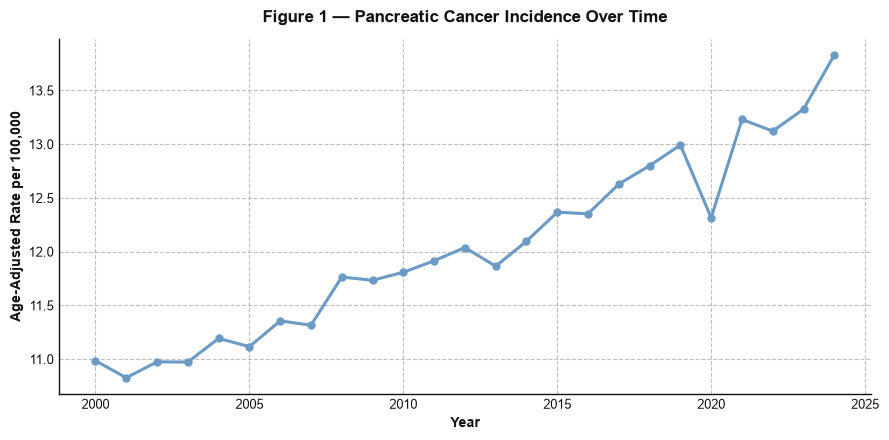

In [422]:
plt.figure(figsize=(9, 4.5))
ax = plt.gca()

plt.plot(
    clean_df[year_col], 
    clean_df[rate_col], 
    marker='o', 
    markersize=5, 
    color='#6B9AC4', 
    linewidth=2.2, 
    label='Incidence Rate'
)

plt.title('Figure 1 — Pancreatic Cancer Incidence Over Time')
plt.xlabel('Year')
plt.ylabel('Age-Adjusted Rate per 100,000')
plt.grid(True, axis='y')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/incidence_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

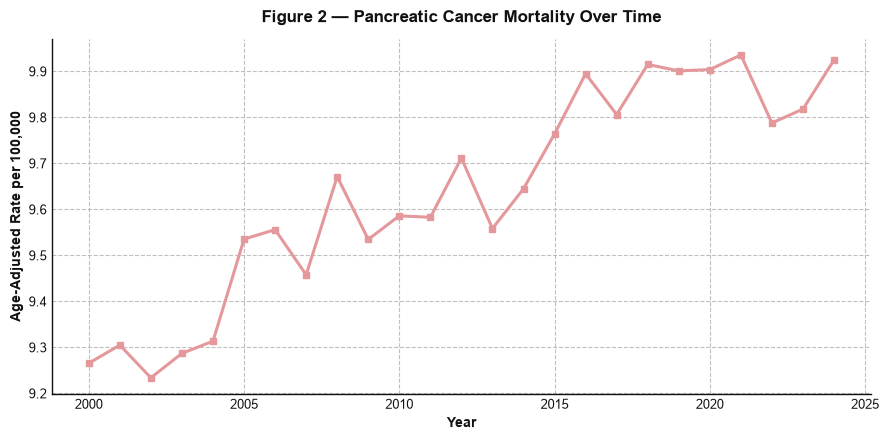

In [423]:
plt.figure(figsize=(9, 4.5))
ax = plt.gca()

plt.plot(
    clean_mortality[mort_year_col], 
    clean_mortality[mort_col], 
    marker='s', 
    markersize=5, 
    color='#E5989B', 
    linewidth=2.2, 
    label='Mortality Rate'
)

plt.title('Figure 2 — Pancreatic Cancer Mortality Over Time')
plt.xlabel('Year')
plt.ylabel('Age-Adjusted Rate per 100,000')
plt.grid(True, axis='y')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/mortality_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

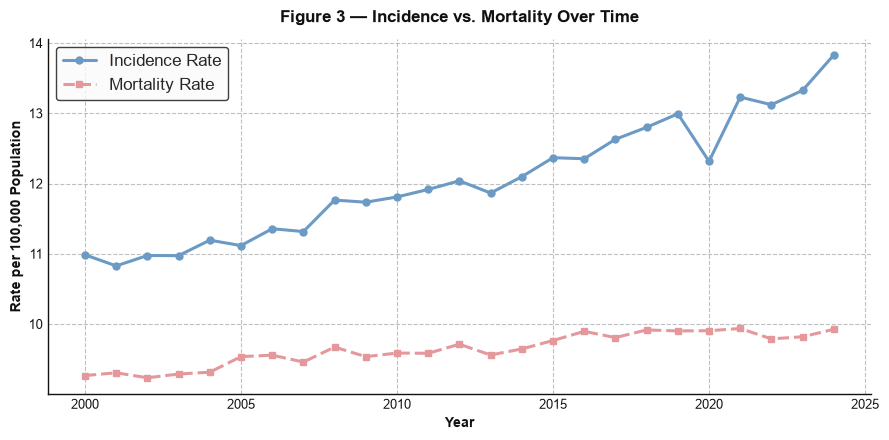

In [424]:
plt.figure(figsize=(9, 4.5))
ax = plt.gca()

plt.plot(
    clean_df[year_col], 
    clean_df[rate_col], 
    marker='o', 
    markersize=5, 
    color='#6B9AC4', 
    linewidth=2.2, 
    label='Incidence Rate'
)

plt.plot(
    clean_mortality[mort_year_col], 
    clean_mortality[mort_col], 
    marker='s', 
    markersize=5, 
    color='#E5989B', 
    linewidth=2.2, 
    linestyle='--', 
    label='Mortality Rate'
)

plt.title('Figure 3 — Incidence vs. Mortality Over Time')
plt.xlabel('Year')
plt.ylabel('Rate per 100,000 Population')
plt.grid(True, axis='y')
plt.legend(loc='upper left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/incidence_vs_mortality.png', dpi=300, bbox_inches='tight')
plt.show()

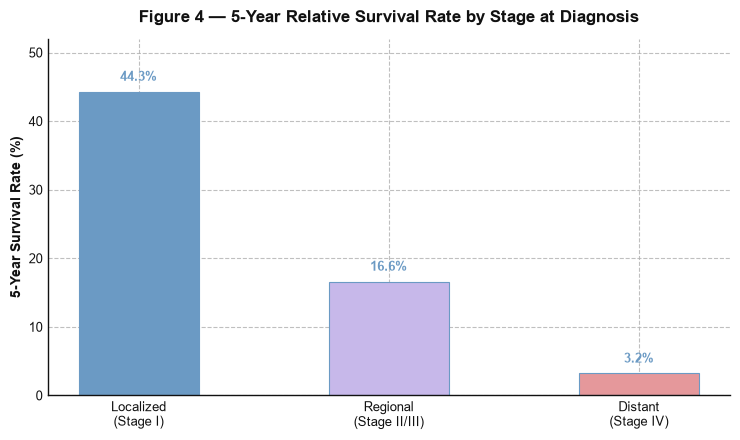

In [425]:
stages = ['Localized\n(Stage I)', 'Regional\n(Stage II/III)', 'Distant\n(Stage IV)']
survival_rates = [44.3, 16.6, 3.2]
colors = ['#6B9AC4', '#C7B8EA', '#E5989B']

plt.figure(figsize=(7.5, 4.5))
ax = plt.gca()

bars = plt.bar(stages, survival_rates, color=colors, width=0.48, edgecolor='#6B9AC4', linewidth=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + 1.2, 
        f"{yval}%", 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        color='#6B9AC4',
        fontsize=9
    )

plt.title('Figure 4 — 5-Year Relative Survival Rate by Stage at Diagnosis')
plt.ylabel('5-Year Survival Rate (%)')
plt.ylim(0, 52)
plt.grid(True, axis='y')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/survival_by_stage.png', dpi=300, bbox_inches='tight')
plt.show()